In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import sys
from pathlib import Path

BASE_DIR = Path.cwd().parent
sys.path.insert(0, str(BASE_DIR / 'scripts'))

from geographic_analysis import country_revenue, segment_by_country
from product_analysis import product_affinity
from cohort_analysis import cohort_matrix, cohort_long

df_clean = pd.read_csv(BASE_DIR / 'data' / 'clean' / 'clean_retail.csv', low_memory=False)
df_rfm   = pd.read_csv(BASE_DIR / 'exports' / 'customer_rmf.csv')

# Purchase-behaviour analyses use sales only (returns are modelled separately)
df_sales = df_clean[df_clean['TransactionType'] == 'Sale']

SEGMENT_ORDER = [
    'Champions', 'Loyal Customers', 'Potential Loyalists',
    'New Customers', 'Promising', 'Need Attention',
    'About to Sleep', 'At Risk', "Can't Lose Them",
    'Hibernating', 'Lost'
]

# 1. Geographic Analysis

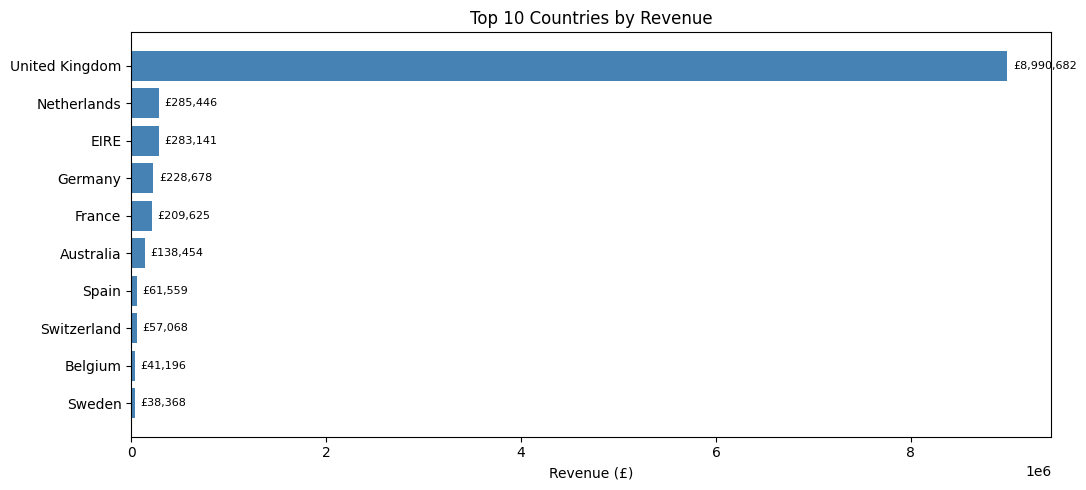

,Country,Revenue,Orders,Customers,RevenueShare
36,United Kingdom,8990682.034,18018,3920,84.57
24,Netherlands,285446.340,94,9,2.69
10,EIRE,283140.520,288,3,2.66
14,Germany,228678.400,457,94,2.15
13,France,209625.370,392,87,1.97
0,Australia,138453.810,57,9,1.30
31,Spain,61558.560,90,30,0.58
33,Switzerland,57067.600,54,21,0.54
3,Belgium,41196.340,98,25,0.39
32,Sweden,38367.830,36,8,0.36


In [2]:
df_country = country_revenue(df_sales)
top10 = df_country.head(10)

fig, ax = plt.subplots(figsize=(11, 5))
bars    = ax.barh(top10['Country'][::-1], top10['Revenue'][::-1], color='steelblue')
ax.bar_label(bars, labels=[f'£{v:,.0f}' for v in top10['Revenue'][::-1]], padding=4, fontsize=8)
ax.set_title('Top 10 Countries by Revenue')
ax.set_xlabel('Revenue (£)')
plt.tight_layout()
plt.show()

df_country[['Country', 'Revenue', 'Orders', 'Customers', 'RevenueShare']].head(10)

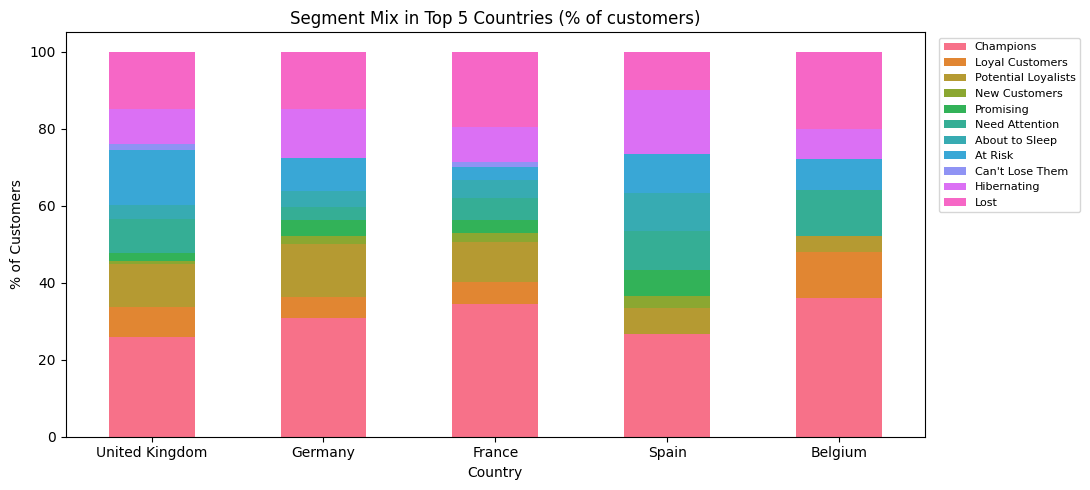

In [3]:
df_segs_by_country = segment_by_country(df_sales, df_rfm)

# Top 5 countries by total customers
country_totals = df_segs_by_country.groupby('Country')['Customers'].sum().sort_values(ascending=False)
top5_countries = country_totals.head(5).index.tolist()

# Pivot the long (Country, Segment, Customers) table into a Country x Segment matrix
df_pivot = (df_segs_by_country[df_segs_by_country['Country'].isin(top5_countries)]
            .pivot_table(index='Country', columns='Segment',
                         values='Customers', aggfunc='sum', fill_value=0)
            .reindex(index=top5_countries))

seg_cols = [s for s in SEGMENT_ORDER if s in df_pivot.columns]
df_plot  = df_pivot[seg_cols]

df_plot_pct = df_plot.div(df_plot.sum(axis=1), axis=0) * 100

df_plot_pct.plot(kind='bar', stacked=True, figsize=(11, 5),
                 color=sns.color_palette('husl', len(seg_cols)), edgecolor='none')
plt.title('Segment Mix in Top 5 Countries (% of customers)')
plt.xlabel('Country')
plt.ylabel('% of Customers')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

# 2. Product Affinity by Segment

In [4]:
df_products = product_affinity(df_sales, df_rfm, top_n=5)

for seg in SEGMENT_ORDER:
    subset = df_products[df_products['Segment'] == seg]
    if subset.empty:
        continue
    print(f'\n-------------------------------------- {seg} --------------------------------------')
    print(subset[['Description', 'Revenue', 'Orders']].to_string(index=False))


-------------------------------------- Champions --------------------------------------
                       Description   Revenue  Orders
          REGENCY CAKESTAND 3 TIER 104838.90     980
WHITE HANGING HEART T-LIGHT HOLDER  67695.35    1178
           JUMBO BAG RED RETROSPOT  61239.18    1106
                     PARTY BUNTING  43127.13     798
     ASSORTED COLOUR BIRD ORNAMENT  40661.38     807

-------------------------------------- Loyal Customers --------------------------------------
                       Description  Revenue  Orders
          REGENCY CAKESTAND 3 TIER 11214.75     178
           JUMBO BAG RED RETROSPOT  9092.52     185
GROW A FLYTRAP OR SUNFLOWER IN TIN  7187.19      47
              FELTCRAFT DOLL MOLLY  7122.80      44
                     PARTY BUNTING  6482.80     154

-------------------------------------- Potential Loyalists --------------------------------------
                 Description   Revenue  Orders
 PAPER CRAFT , LITTLE BIRDIE 168469.60  

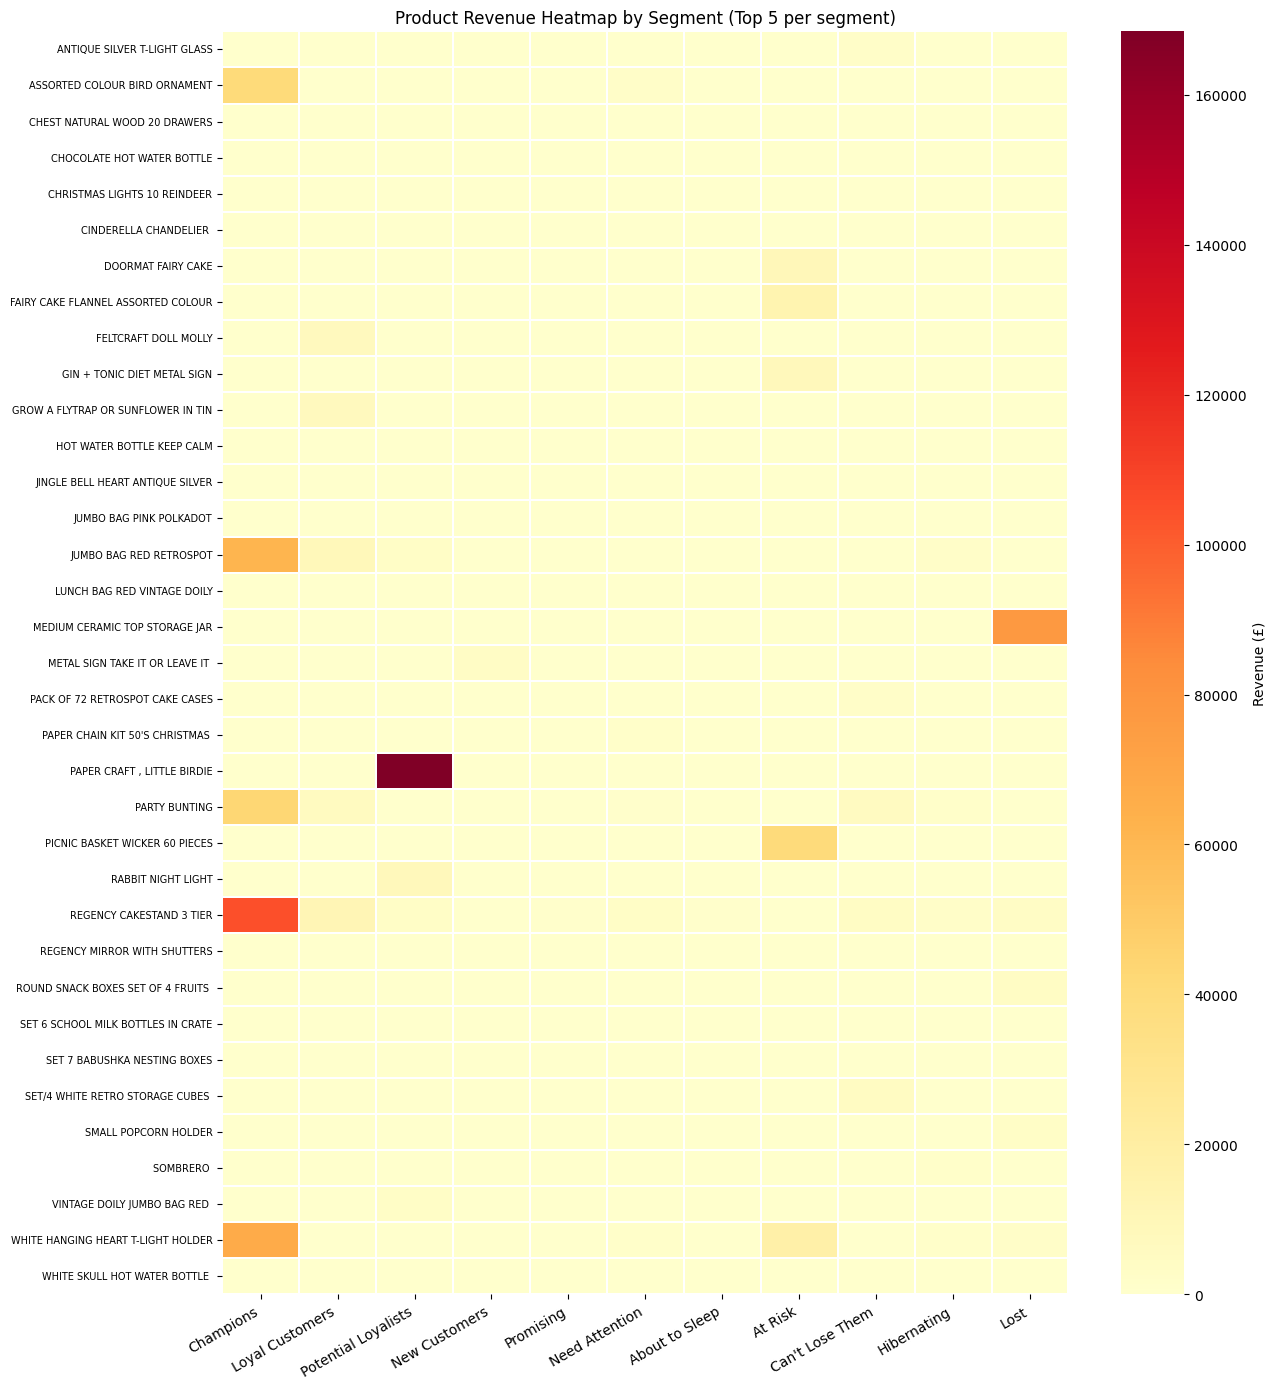

In [5]:
# Heatmap: top 5 products per segment by revenue
df_pivot = (df_products.pivot_table(index='Description', columns='Segment',
                                    values='Revenue', aggfunc='sum', fill_value=0))

# Keep only segments present in current data, in order
seg_cols = [s for s in SEGMENT_ORDER if s in df_pivot.columns]
df_pivot = df_pivot[seg_cols]

fig, ax = plt.subplots(figsize=(13, max(6, len(df_pivot) * 0.4)))
sns.heatmap(df_pivot, cmap='YlOrRd', linewidths=0.3, ax=ax,
            cbar_kws={'label': 'Revenue (£)'})
ax.set_title('Product Revenue Heatmap by Segment (Top 5 per segment)')
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=30, ha='right')
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

# 3. Cohort Retention Analysis

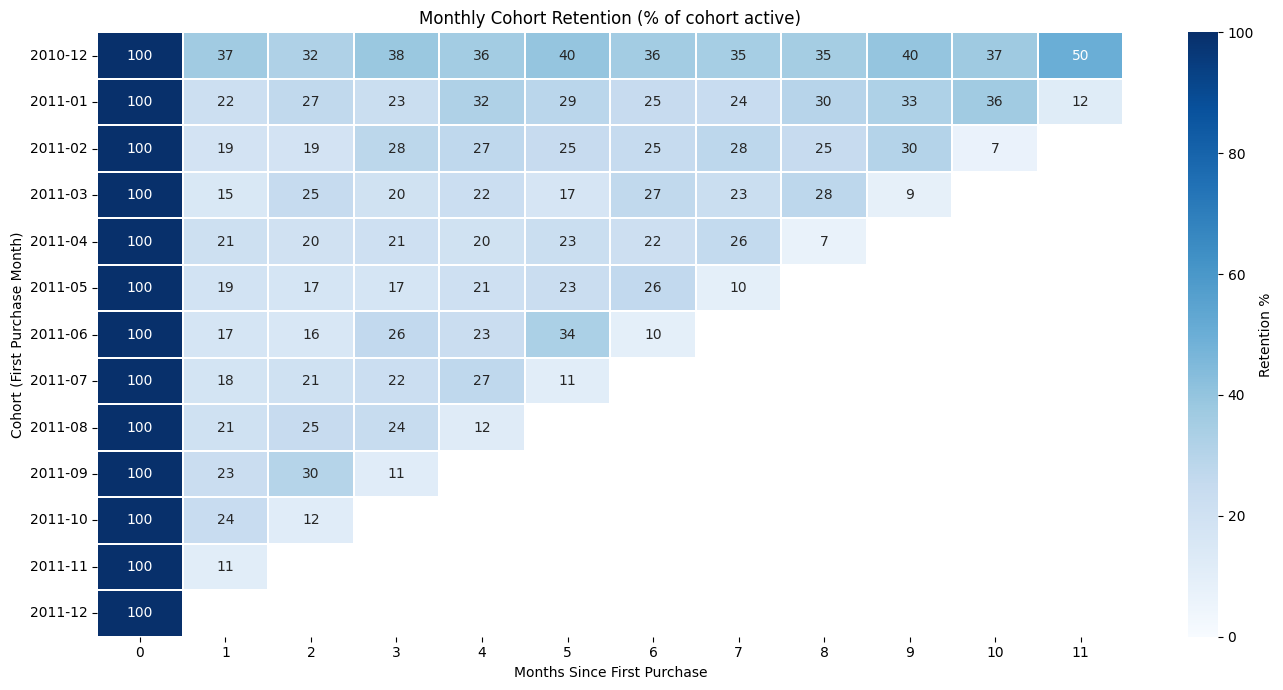

In [6]:
df_cohort_w, df_retention_w = cohort_matrix(df_sales)

# cohort_long drops not-yet-observable months; pivot to cohort x months-elapsed.
# (cohort_matrix renames columns to 'Month_n_Pct' strings, so the long helper is
#  the reliable way to get a numeric MonthsElapsed axis.)
clong = cohort_long(df_cohort_w, df_retention_w)
df_ret_plot = clong.pivot(index='CohortMonth', columns='MonthsElapsed', values='RetentionPct')

# Limit to the first year of follow-up (months 0-11)
df_ret_plot = df_ret_plot[[c for c in df_ret_plot.columns if c <= 11]]

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    df_ret_plot,
    annot=True, fmt='.0f', cmap='Blues',
    linewidths=0.3, ax=ax,
    cbar_kws={'label': 'Retention %'},
    vmin=0, vmax=100
)
ax.set_title('Monthly Cohort Retention (% of cohort active)')
ax.set_xlabel('Months Since First Purchase')
ax.set_ylabel('Cohort (First Purchase Month)')
plt.tight_layout()
plt.show()

# 4. Segment Behavioral Profiles & Marketing Recommendations

---

## Champions
**Profile:** Bought recently, buy often, spend the most. The core of the business.  
1. Enroll in a VIP loyalty programme with early access to new products and exclusive discounts.
2. Launch a referral incentive — Champions are the most credible advocates.
3. Send personalised thank-you communications and request reviews or testimonials.

---

## Loyal Customers
**Profile:** Buy regularly and recently, just below the top spenders.  
1. Introduce tiered membership with an upgrade path toward Champions status.
2. Offer personalised cross-category product recommendations based on purchase history.
3. Run exclusive member-only sales events to reward continued loyalty.

---

## Potential Loyalists
**Profile:** Recent customers with average frequency — building a habit.  
1. Offer membership or a loyalty programme to lock in repeat behaviour.
2. Recommend complementary products to broaden their basket.
3. Keep them engaged with personalised content shortly after each purchase.

---

## New Customers
**Profile:** Bought very recently for the first time. High potential, low certainty.  
1. Trigger an onboarding email sequence: welcome, product guides, popular items.
2. Offer a second-purchase incentive (discount or free shipping) within 30 days.
3. Ask for feedback on the first experience to identify and remove friction.

---

## Promising
**Profile:** Recent shoppers who have not bought much yet — early stage but engaged.  
1. Offer a time-limited discount on a complementary product to drive the second purchase.
2. Send curated product discovery emails based on the first purchase category.
3. Invite to a review or wishlist programme to deepen engagement.

---

## Need Attention
**Profile:** Above-average recency and frequency but slipping — could go either way.  
1. Send targeted product bundle offers to increase average order value.
2. Highlight new arrivals in categories they have previously purchased from.
3. Use limited-time promotions to create urgency and push them toward Loyal status.

---

## About to Sleep
**Profile:** Below-average recency and low frequency — fading out before they lapse.  
1. Share popular products and renewed-interest discounts before they go dormant.
2. Leverage seasonal moments (holidays, sale periods) to prompt return visits.
3. Simplify the path to repurchase: pre-filled cart with their most-bought items.

---

## At Risk
**Profile:** Used to buy often and spend well, but haven't purchased in a long time.  
1. Launch a targeted win-back campaign with a meaningful discount or free gift.
2. Send a satisfaction survey to understand why they stopped — and act on the results.
3. Retarget with ads featuring products similar to past purchases.

---

## Can't Lose Them
**Profile:** Were among the most frequent buyers, now inactive. High revenue impact.  
1. Assign to a personal outreach channel (direct email or phone for B2B accounts).
2. Offer a premium re-engagement package: exclusive discount plus priority service.
3. Flag for account manager review — do not lose them to competitors.

---

## Hibernating
**Profile:** Long since last purchase, with low past engagement.  
1. Run low-cost reactivation: seasonal newsletters and relevant discounts.
2. Test a single strong revival offer; suppress if there is no response.
3. Keep contact frequency low to protect deliverability and margin.

---

## Lost
**Profile:** Lowest recency and frequency scores. Minimal expected value.  
1. Include in broad campaigns only; attempt one last-chance reactivation offer.
2. If no response, move to a suppression list to reduce marketing spend.
3. Analyse common traits (product categories, geography) to avoid acquiring similar low-LTV customers in future.

In [7]:
# Segment summary table
summary = (df_rfm.groupby('Segment')
                 .agg(
                     Customers=('CustomerID', 'count'),
                     Avg_Recency=('Recency', 'mean'),
                     Avg_Frequency=('Frequency', 'mean'),
                     Avg_Monetary=('Monetary', 'mean'),
                     Total_Revenue=('Monetary', 'sum')
                 )
                 .round(1)
                 .reindex([s for s in SEGMENT_ORDER if s in df_rfm['Segment'].unique()])
)
summary['Revenue_Share_%'] = (summary['Total_Revenue'] / summary['Total_Revenue'].sum() * 100).round(1)
summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Revenue_Share_%
Segment,,,,,,
Champions,1121,12.0,10.1,5225.5,5857798.9,65.9
Loyal Customers,329,48.0,5.7,2455.2,807776.9,9.1
Potential Loyalists,477,15.6,2.0,1040.2,496163.2,5.6
New Customers,42,5.9,1.0,385.0,16170.9,0.2
Promising,95,22.0,1.0,360.9,34286.5,0.4
Need Attention,373,50.5,1.8,692.3,258243.9,2.9
About to Sleep,166,52.2,1.0,416.0,69052.7,0.8
At Risk,596,151.8,2.9,1079.4,643312.2,7.2
Can't Lose Them,65,129.6,8.4,2778.5,180600.2,2.0
